Baseball Analytics: Team Strategy and In-Game Decision-Making

Lineup construction
bullpen usage
situational tactics

In [1]:
import pandas as pd
import sqlite3
# path to database
DB_PATH=r"C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Sports/baseball_pump.db"
conn = sqlite3.connect(DB_PATH)

In [2]:
# Query all tables
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

# Close connection
conn.close()

       name
0  statcast


In [3]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM statcast", conn)
conn.close()

In [4]:
print(df['description'].head())

0    hit_into_play
1             ball
2             ball
3             foul
4             ball
Name: description, dtype: object


In [5]:
# column names
print(df.columns.tolist())

# ['pitch_type', 'game_date', 'release_speed', 'release_pos_x', 'release_pos_z', 'player_name', 'batter', 'pitcher', 'events', 'description',
#  'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 
# 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'on_3b', 
# 'on_2b', 'on_1b', 'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y', 'tfs_deprecated', 'tfs_zulu_deprecated', 'umpire', 'sv_id', 'vx0', 
# 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed', 'release_spin_rate', 
# 'release_extension', 'game_pk', 'fielder_2', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 
# 'release_pos_y', 'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle', 'woba_value', 'woba_denom', 'babip_value', 'iso_value', 
# 'launch_speed_angle', 'at_bat_number', 'pitch_number', 'pitch_name', 'home_score', 'away_score', 'bat_score', 'fld_score', 'post_away_score', 
# 'post_home_score', 'post_bat_score', 'post_fld_score', 'if_fielding_alignment', 'of_fielding_alignment', 'spin_axis', 'delta_home_win_exp', 
# 'delta_run_exp', 'bat_speed', 'swing_length', 'estimated_slg_using_speedangle', 'delta_pitcher_run_exp', 'hyper_speed', 'home_score_diff', 
# 'bat_score_diff', 'home_win_exp', 'bat_win_exp', 'age_pit_legacy', 'age_bat_legacy', 'age_pit', 'age_bat', 'n_thruorder_pitcher', 
# 'n_priorpa_thisgame_player_at_bat', 'pitcher_days_since_prev_game', 'batter_days_since_prev_game', 'pitcher_days_until_next_game', 
# 'batter_days_until_next_game', 'api_break_z_with_gravity', 'api_break_x_arm', 'api_break_x_batter_in', 'arm_angle', 'attack_angle', 
# 'attack_direction', 'swing_path_tilt', 'intercept_ball_minus_batter_pos_x_inches', 'intercept_ball_minus_batter_pos_y_inches']

['pitch_type', 'game_date', 'release_speed', 'release_pos_x', 'release_pos_z', 'player_name', 'batter', 'pitcher', 'events', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y', 'tfs_deprecated', 'tfs_zulu_deprecated', 'umpire', 'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed', 'release_spin_rate', 'release_extension', 'game_pk', 'fielder_2', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y', 'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle', 'woba_value', 'woba_denom', 'babip_value', 'iso_value', 'launch_speed_a

In [19]:
print(df['p_throws'].head())

0    R
1    R
2    R
3    R
4    R
Name: p_throws, dtype: object


Lineup

In [21]:
# Filter only balls put into play against R-handed pitchers
batter_df_Right = df[(df['description'] == 'hit_into_play') & (df['p_throws'] == 'R')]

# Filter only balls put into play against L-handed pitchers
batter_df_Left = df[(df['description'] == 'hit_into_play') & (df['p_throws'] == 'L')]

# Aggregate stats per batter per year
batter_df_Right = (
    batter_df_Right
    .groupby(['game_year', 'batter'], as_index=False)
    .agg({
        'estimated_ba_using_speedangle': 'mean',    # On-base ability
        'estimated_slg_using_speedangle': 'mean',   # Power
        'delta_run_exp': 'mean',                     # Run contribution
        'hyper_speed': 'mean',                       # Base running
        'at_bat_number': 'count'                     # Count of balls in play
    })
    .rename(columns={'at_bat_number': 'hits_into_play'})
)

# Create a composite score for each player
batter_df_Right['lineup_score'] = (
    0.4 * batter_df_Right['estimated_ba_using_speedangle'] +
    0.3 * batter_df_Right['estimated_slg_using_speedangle'] +
    0.2 * batter_df_Right['delta_run_exp'] +
    0.1 * batter_df_Right['hyper_speed']
)

# Aggregate stats per batter per year
batter_df_Left = (
    batter_df_Left
    .groupby(['game_year', 'batter'], as_index=False)
    .agg({
        'estimated_ba_using_speedangle': 'mean',    # On-base ability
        'estimated_slg_using_speedangle': 'mean',   # Power
        'delta_run_exp': 'mean',                     # Run contribution
        'hyper_speed': 'mean',                       # Base running
        'at_bat_number': 'count'                     # Count of balls in play
    })
    .rename(columns={'at_bat_number': 'hits_into_play'})
)

# Create a composite score for each player
batter_df_Left['lineup_score'] = (
    0.4 * batter_df_Left['estimated_ba_using_speedangle'] +
    0.3 * batter_df_Left['estimated_slg_using_speedangle'] +
    0.2 * batter_df_Left['delta_run_exp'] +
    0.1 * batter_df_Left['hyper_speed']
)

Calinski-Harabasz Scores:
2 clusters: 1310.96
3 clusters: 1866.43
4 clusters: 2215.10
5 clusters: 2255.18
6 clusters: 2507.71

Cluster Means:
         estimated_ba_using_speedangle  lineup_score
cluster                                             
0.0                           0.302311      9.530252
1.0                           0.601516     10.896273
2.0                           0.160302      9.003601
3.0                           0.354042      9.913379

Counts per Cluster:
         hits_into_play
cluster                
0.0                 745
1.0                  70
2.0                 246
3.0                 507


c:\Users\tyler\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\tyler\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\tyler\AppData\Local\spyder-6\envs\spyder-runtime\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\tyler\AppData\Local\spyder-6

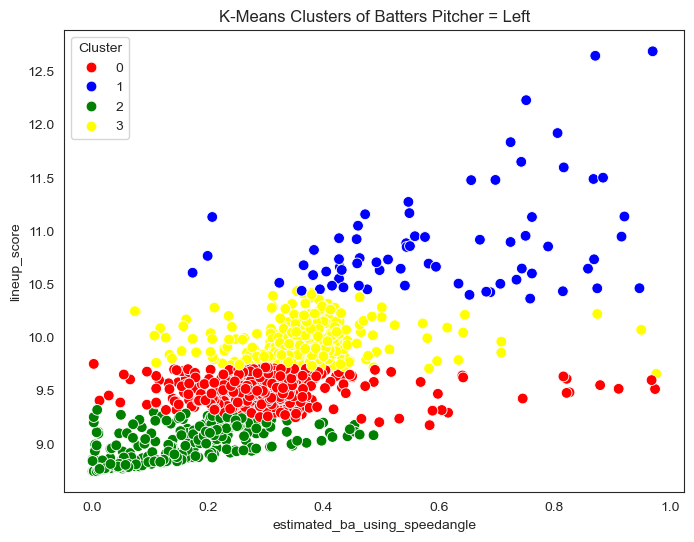

Calinski-Harabasz Scores:
2 clusters: 1696.27
3 clusters: 2554.58
4 clusters: 2918.24
5 clusters: 3246.57
6 clusters: 3356.51

Cluster Means:
         estimated_ba_using_speedangle  lineup_score
cluster                                             
0.0                           0.153196      8.996351
1.0                           0.304078      9.567234
2.0                           0.609730     11.228065
3.0                           0.369022     10.016170

Counts per Cluster:
         hits_into_play
cluster                
0.0                 330
1.0                1046
2.0                  77
3.0                 525


C:\Users\tyler\AppData\Local\Temp\ipykernel_29748\2283309114.py:130: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(data=tocluster, x=var1, y=var2, hue='cluster', palette=customPalette, s=60)


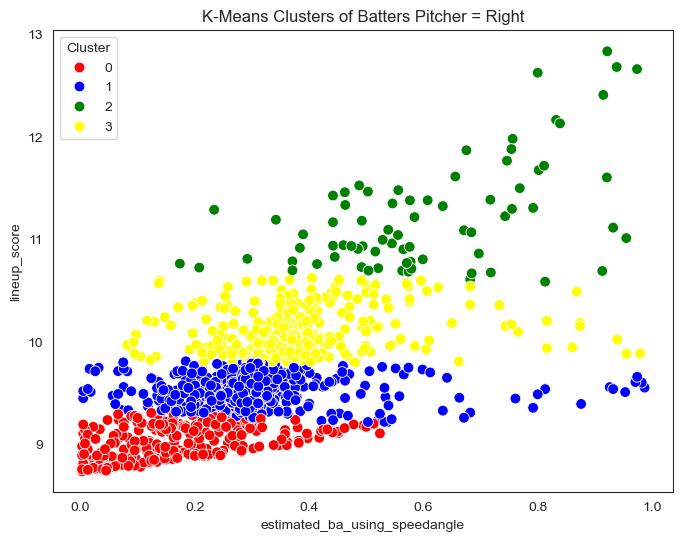

In [23]:
# pitcher = Left 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

# Variables to cluster
var1 = 'estimated_ba_using_speedangle'
var2 = 'lineup_score'
Constant = 'hits_into_play'

# -----------------------------
# 1. Prepare data for clustering
# -----------------------------
# Select columns and drop rows with missing values
tocluster = batter_df_Left[[var1, var2, Constant]].dropna(subset=[var1, var2])

# -----------------------------
# 2. Try different cluster counts with Calinski-Harabasz Index
# -----------------------------
print("Calinski-Harabasz Scores:")
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(tocluster[[var1, var2]])
    ch_score = calinski_harabasz_score(tocluster[[var1, var2]], kmeans.labels_)
    print(f"{i} clusters: {ch_score:.2f}")

# -----------------------------
# 3. Apply K-Means with chosen number of clusters
# -----------------------------
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(tocluster[[var1, var2]])
clusters = kmeans.labels_

# Assign clusters to the dataframe
tocluster['cluster'] = clusters
batter_df_Left.loc[tocluster.index, 'cluster'] = clusters

# -----------------------------
# 4. Cluster summary
# -----------------------------
# Mean values per cluster
cluster_means = batter_df_Left.groupby('cluster')[[var1, var2]].mean()
# Count of players (or hits_into_play) per cluster
cluster_counts = batter_df_Left.groupby('cluster')[[Constant]].count()

print("\nCluster Means:")
print(cluster_means)
print("\nCounts per Cluster:")
print(cluster_counts)

# -----------------------------
# 5. Plot clusters
# -----------------------------
sns.set_style('white')
customPalette = ['red', 'blue', 'green', 'yellow', 'black']
sns.set_palette(customPalette)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tocluster, x=var1, y=var2, hue='cluster', palette=customPalette, s=60)
plt.title("K-Means Clusters of Batters Pitcher = Left")
plt.xlabel(var1)
plt.ylabel(var2)
plt.legend(title="Cluster")
plt.show()

# pitcher = Right 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

# Variables to cluster
var1 = 'estimated_ba_using_speedangle'
var2 = 'lineup_score'
Constant = 'hits_into_play'

# -----------------------------
# 1. Prepare data for clustering
# -----------------------------
# Select columns and drop rows with missing values
tocluster = batter_df_Right[[var1, var2, Constant]].dropna(subset=[var1, var2])

# -----------------------------
# 2. Try different cluster counts with Calinski-Harabasz Index
# -----------------------------
print("Calinski-Harabasz Scores:")
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(tocluster[[var1, var2]])
    ch_score = calinski_harabasz_score(tocluster[[var1, var2]], kmeans.labels_)
    print(f"{i} clusters: {ch_score:.2f}")

# -----------------------------
# 3. Apply K-Means with chosen number of clusters
# -----------------------------
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(tocluster[[var1, var2]])
clusters = kmeans.labels_

# Assign clusters to the dataframe
tocluster['cluster'] = clusters
batter_df_Right.loc[tocluster.index, 'cluster'] = clusters

# -----------------------------
# 4. Cluster summary
# -----------------------------
# Mean values per cluster
cluster_means = batter_df_Right.groupby('cluster')[[var1, var2]].mean()
# Count of players (or hits_into_play) per cluster
cluster_counts = batter_df_Right.groupby('cluster')[[Constant]].count()

print("\nCluster Means:")
print(cluster_means)
print("\nCounts per Cluster:")
print(cluster_counts)

# -----------------------------
# 5. Plot clusters
# -----------------------------
sns.set_style('white')
customPalette = ['red', 'blue', 'green', 'yellow', 'black']
sns.set_palette(customPalette)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tocluster, x=var1, y=var2, hue='cluster', palette=customPalette, s=60)
plt.title("K-Means Clusters of Batters Pitcher = Right")
plt.xlabel(var1)
plt.ylabel(var2)
plt.legend(title="Cluster")
plt.show()

0 core guys 
1 guys to hide 
2 best hitters
3 sandwich cluster 1

bullpen usage